# **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
palette = sns.color_palette("Set1")
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# **Data Exploration**

In [2]:
df=pd.read_csv('/kaggle/input/medical-costs/medical_costs.csv')
df.head(1)

,Age,Sex,BMI,Children,Smoker,Region,Medical Cost
0,58,male,15.6,2,yes,northwest,17907.54


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           10000 non-null  int64  
 1   Sex           10000 non-null  object 
 2   BMI           10000 non-null  float64
 3   Children      10000 non-null  int64  
 4   Smoker        10000 non-null  object 
 5   Region        10000 non-null  object 
 6   Medical Cost  10000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB


In [4]:
df.columns

Index(['Age', 'Sex', 'BMI', 'Children', 'Smoker', 'Region', 'Medical Cost'], dtype='object')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,41.678400,13.807724,18.00,30.000,42.00,54.0000,65.00
BMI,10000.0,27.403010,7.228960,15.00,21.100,27.40,33.7000,40.00
Children,10000.0,2.501700,1.701672,0.00,1.000,2.00,4.0000,5.00
Medical Cost,10000.0,11898.932216,6073.875834,3617.09,5909.925,7957.43,17931.9625,20268.21


In [6]:
df.isnull().sum()

Age             0
Sex             0
BMI             0
Children        0
Smoker          0
Region          0
Medical Cost    0
dtype: int64

In [7]:
df.duplicated().sum()

0

# **Data Preprocessing & Data visualization**

**What is the distribution of all columns?**

In [8]:
age_counts=df['Age'].value_counts().reset_index().sort_values(by='count',ascending=False)

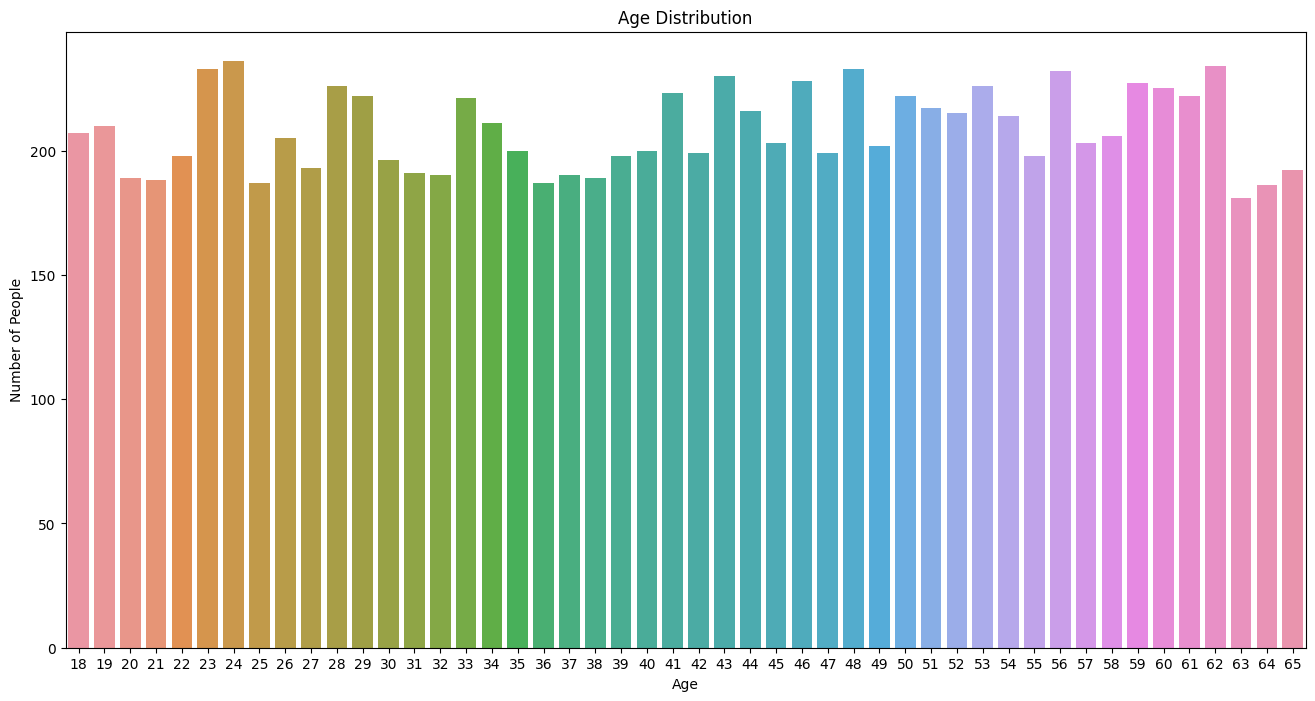

In [9]:
plt.figure(figsize=(16,8))
sns.barplot(age_counts, x='Age', y='count')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.title('Age Distribution')
plt.show()

In [10]:
sex_counts = df['Sex'].value_counts()
sex_counts

Sex
female    5034
male      4966
Name: count, dtype: int64

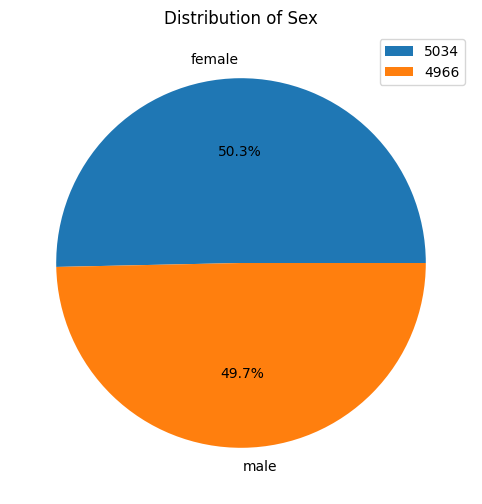

In [11]:
plt.figure(figsize=(12,6))
plt.pie(sex_counts, labels=sex_counts.index,autopct='%1.1f%%')
plt.title('Distribution of Sex')
plt.legend(sex_counts)
plt.show()

In [12]:
smoker_count=df['Smoker'].value_counts()
smoker_count

Smoker
no     5008
yes    4992
Name: count, dtype: int64

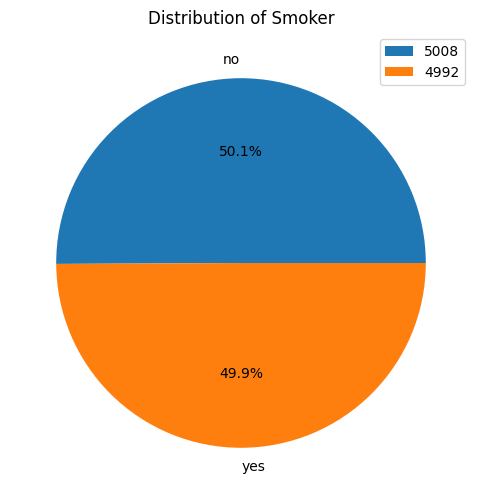

In [13]:
plt.figure(figsize=(12,6))
plt.pie(smoker_count, labels=smoker_count.index,autopct='%1.1f%%')
plt.title('Distribution of Smoker')
plt.legend(smoker_count)
plt.show()

In [14]:
region_count=df['Region'].value_counts()
region_count

Region
southwest    2521
northeast    2514
northwest    2486
southeast    2479
Name: count, dtype: int64

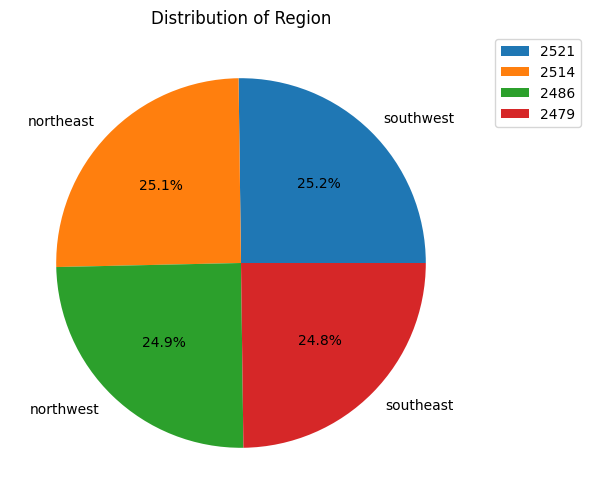

In [15]:
plt.figure(figsize=(12,6))
plt.pie(region_count, labels=region_count.index,autopct='%1.1f%%')
plt.title('Distribution of Region')
plt.legend(region_count,bbox_to_anchor=(1.25, 1))
plt.show()

In [16]:
child_count=df['Children'].value_counts().reset_index().sort_values(by='count',ascending=False)
child_count

,Children,count
0,2,1692
1,1,1683
2,3,1679
3,5,1665
4,4,1647
5,0,1634


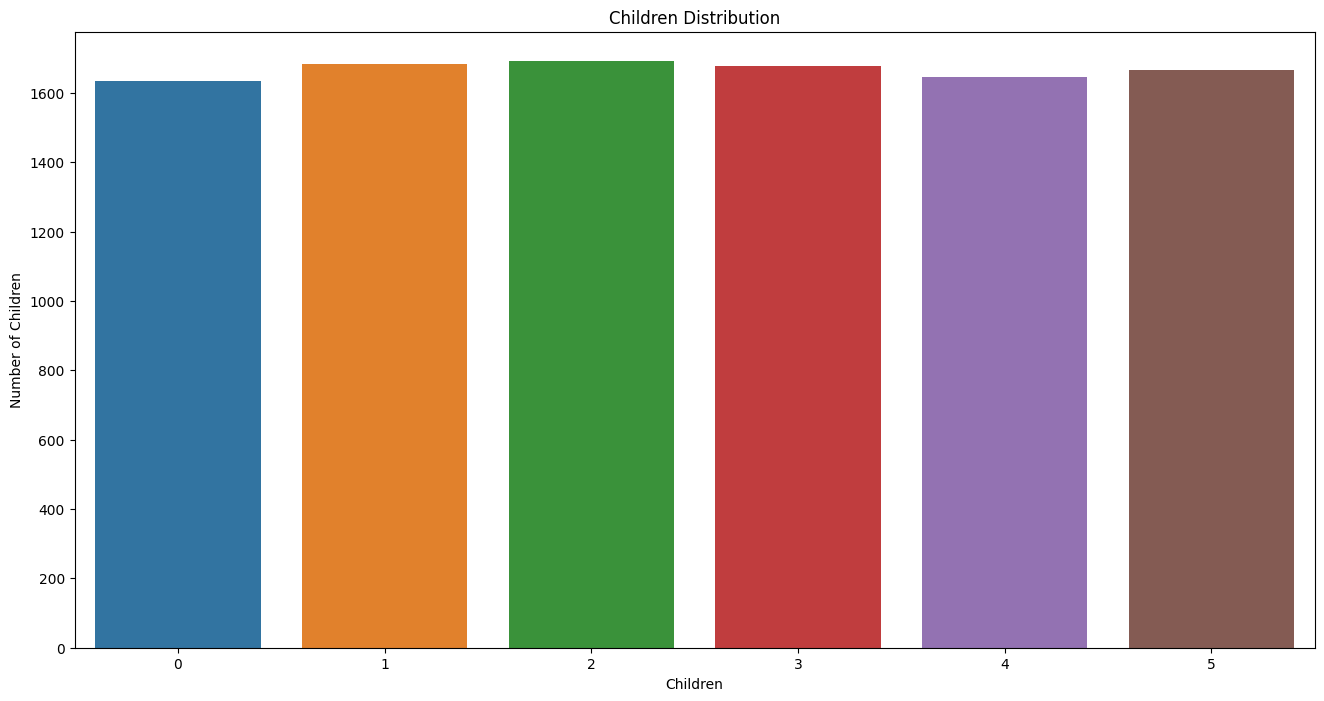

In [17]:
plt.figure(figsize=(16,8))
sns.barplot(child_count, x='Children', y='count')
plt.xlabel('Children')
plt.ylabel('Number of Children')
plt.title('Children Distribution')
plt.show()

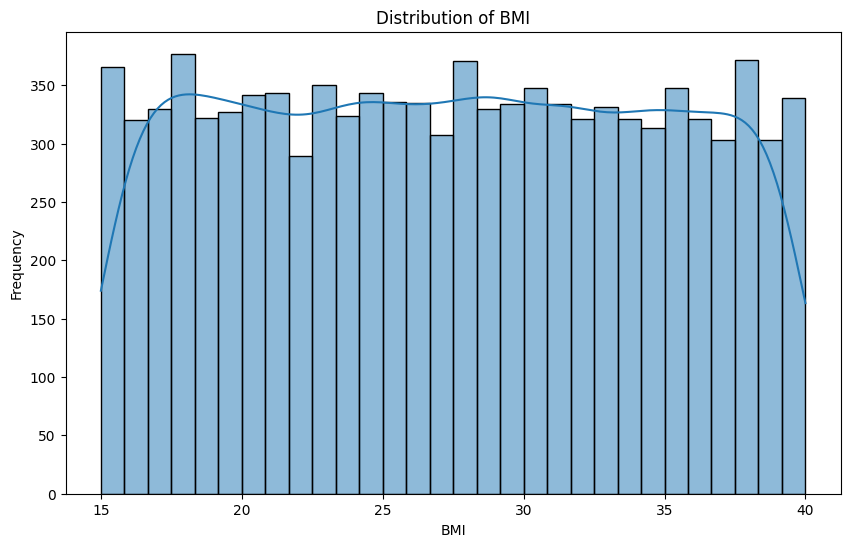

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

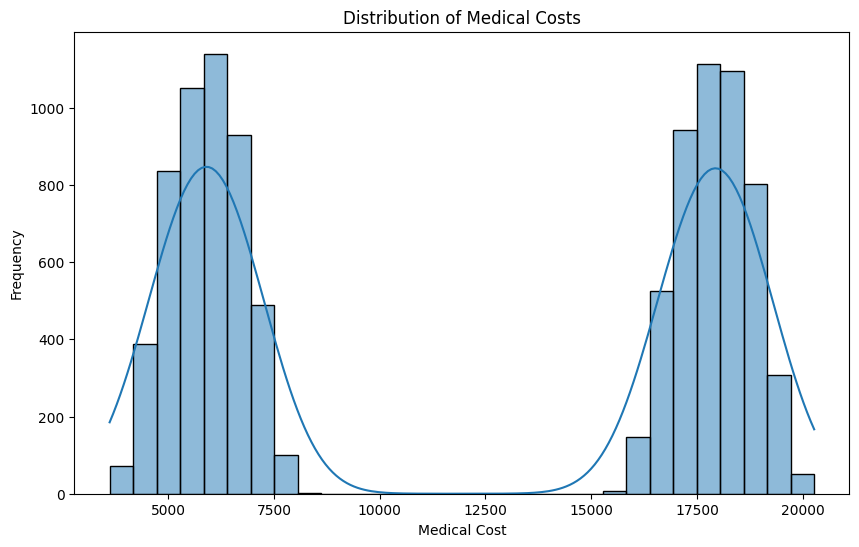

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Medical Cost'], bins=30, kde=True)
plt.title('Distribution of Medical Costs')
plt.xlabel('Medical Cost')
plt.ylabel('Frequency')
plt.show()

**What Is The Total Medical Cost by Age and Smoker Status?**

In [20]:
smoker_medical_cost=df.groupby(['Smoker','Age','Sex']).agg(Total_Medical_Cost=('Medical Cost', 'sum')).reset_index()
smoker_medical_cost

,Smoker,Age,Sex,Total_Medical_Cost
0,no,18,female,286622.72
1,no,18,male,246091.07
2,no,19,female,239168.59
3,no,19,male,256662.86
4,no,20,female,237561.67
...,...,...,...,...
187,yes,63,male,925365.72
188,yes,64,female,989343.20
189,yes,64,male,818391.92
190,yes,65,female,972377.71


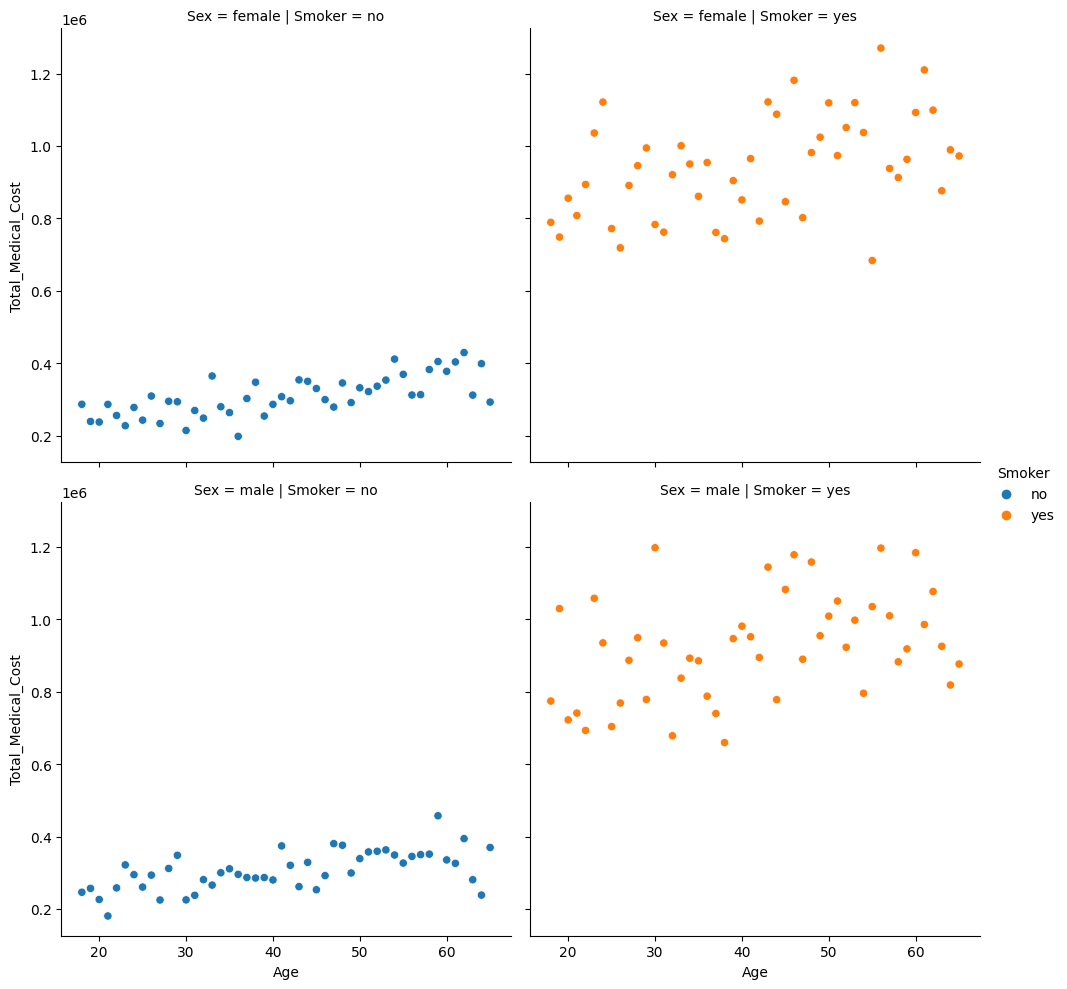

In [21]:
sns.relplot(data=smoker_medical_cost, x="Age", y="Total_Medical_Cost", hue="Smoker", col="Smoker",row="Sex")
plt.xlabel('Age')
plt.ylabel('Total Medical Cost')
plt.show()

**What Is Average BMI by Age and Smoker Status?**

In [22]:
smoker_bmi_mean=df.groupby(['Smoker','Age','Sex']).agg(bmi_average=('BMI', 'mean')).reset_index()
smoker_bmi_mean

,Smoker,Age,Sex,bmi_average
0,no,18,female,28.222951
1,no,18,male,25.009434
2,no,19,female,24.501961
3,no,19,male,27.275472
4,no,20,female,26.616667
...,...,...,...,...
187,yes,63,male,26.155102
188,yes,64,female,28.434615
189,yes,64,male,27.211628
190,yes,65,female,26.301961


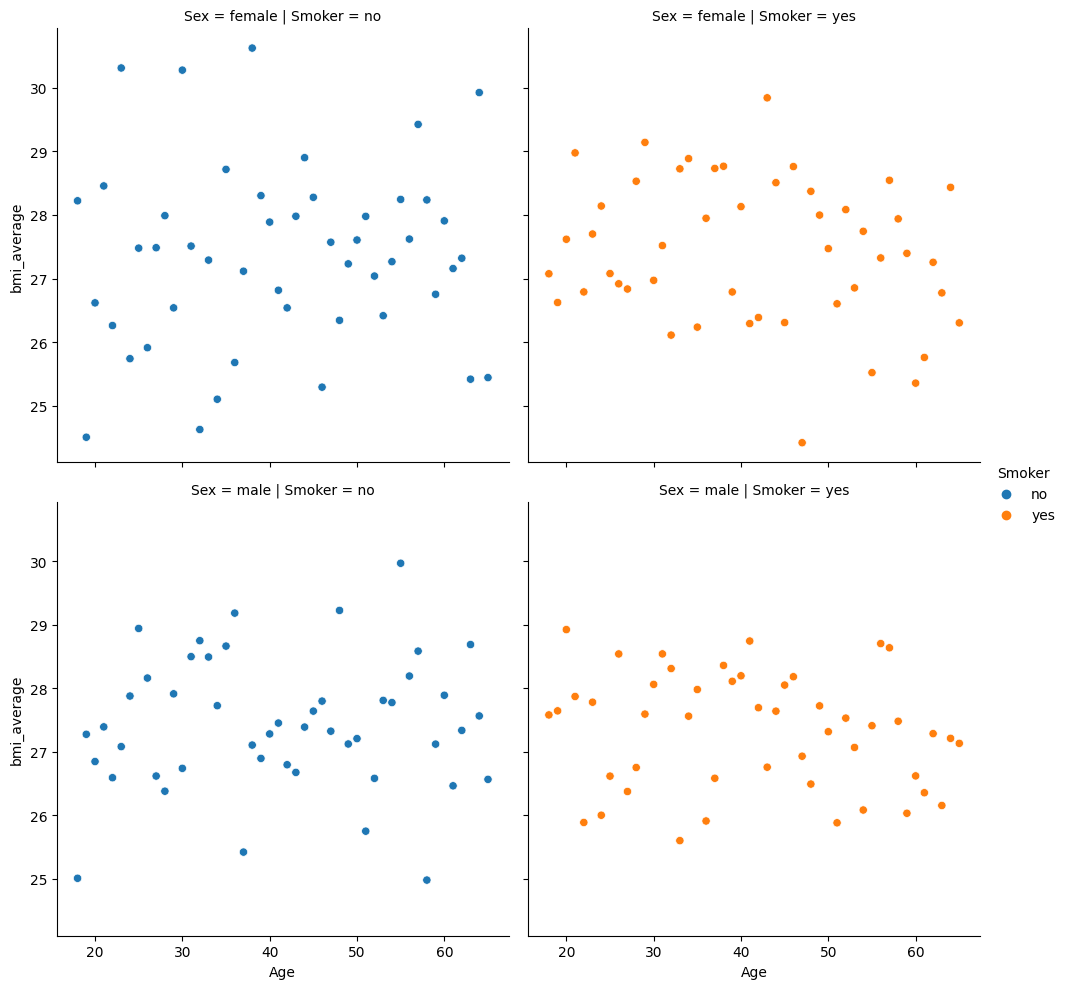

In [23]:
sns.relplot(data=smoker_bmi_mean, x="Age", y="bmi_average", hue="Smoker", col="Smoker",row="Sex")
plt.xlabel('Age')
plt.ylabel('Total Medical Cost')
plt.show()

**What is the relationship between age and medical costs (for smoker and sex)?**

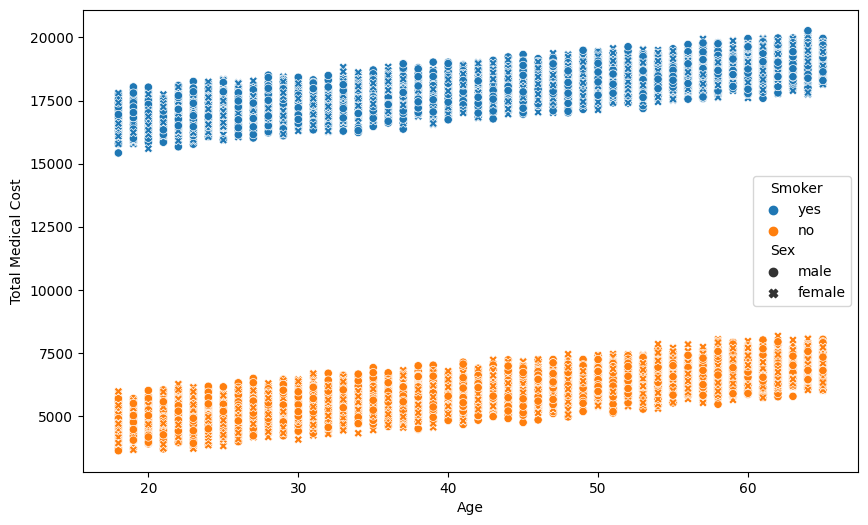

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(df,x='Age',y='Medical Cost',hue='Smoker',style='Sex')
plt.xlabel('Age')
plt.ylabel('Total Medical Cost')
plt.show()

**What is it correlation between (BMI vs Medical Cost)and (Age vs Medical Cost)for smoker and sex ?**

In [25]:
correlation1=df['BMI'].corr(df['Medical Cost'])

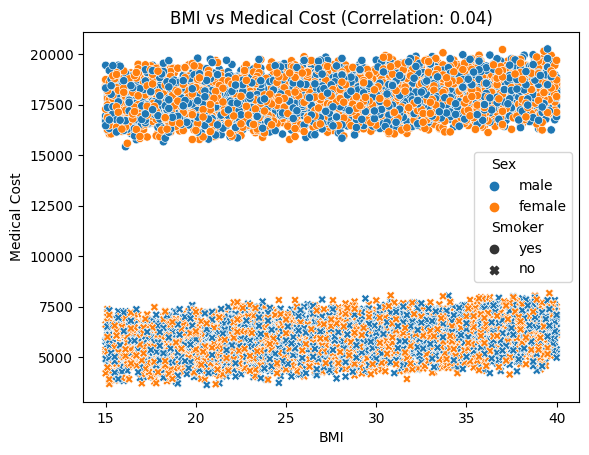

In [26]:
sns.scatterplot(x='BMI', y='Medical Cost',hue='Sex',style='Smoker', data=df)
plt.title(f"BMI vs Medical Cost (Correlation: {correlation1:.2f})")
plt.show()

In [27]:
correlation2=df['Age'].corr(df['Medical Cost'])

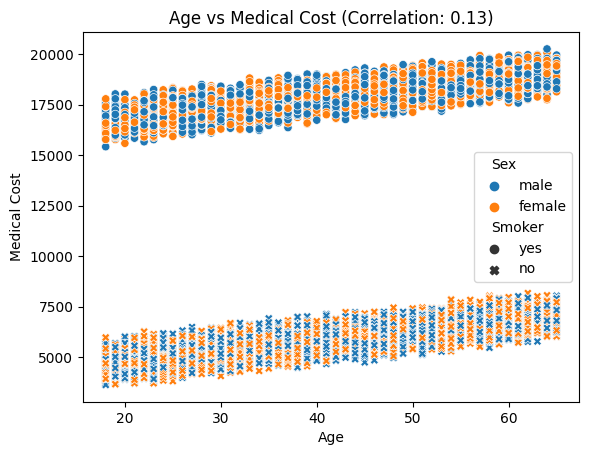

In [28]:
sns.scatterplot(x='Age', y='Medical Cost',hue='Sex',style='Smoker' ,data=df)
plt.title(f"Age vs Medical Cost (Correlation: {correlation2:.2f})")
plt.show()

**What Is The Total Medical Cost by Region and Smoker Status?**

In [29]:
region_medical_cost=df.groupby(['Smoker','Region','Sex']).agg(Total_Medical_Cost=('Medical Cost', 'sum')).reset_index()
region_medical_cost

,Smoker,Region,Sex,Total_Medical_Cost
0,no,northeast,female,3752929.75
1,no,northeast,male,3667082.36
2,no,northwest,female,3701290.95
3,no,northwest,male,3692953.82
4,no,southeast,female,3578107.64
5,no,southeast,male,3593452.16
6,no,southwest,female,3785390.53
7,no,southwest,male,3750227.11
8,yes,northeast,female,11202958.83
9,yes,northeast,male,11329945.30


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:712: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


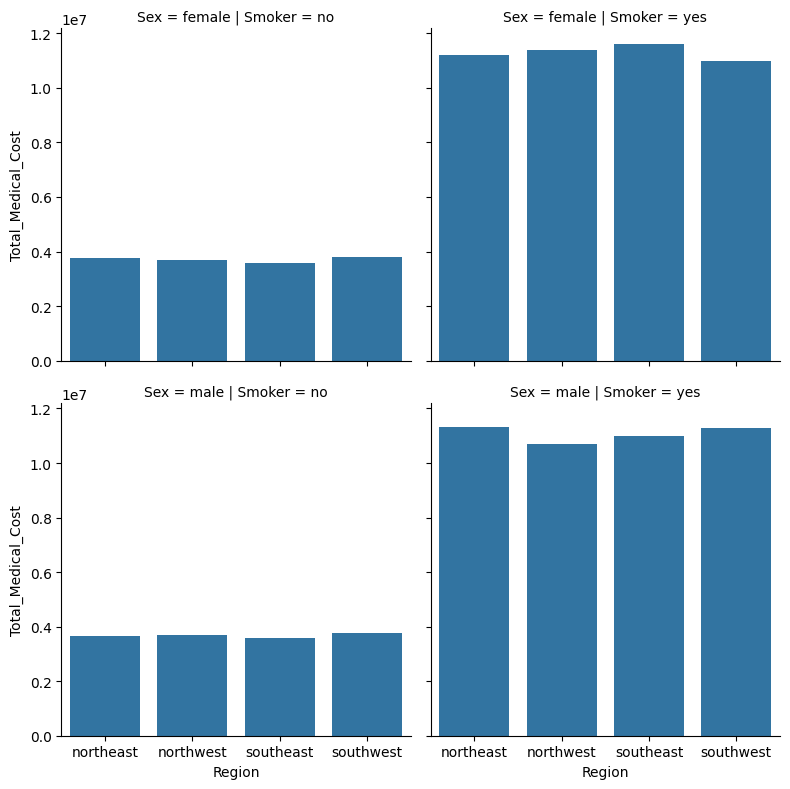

In [30]:
g = sns.FacetGrid(region_medical_cost, col="Smoker", row="Sex", height=4)
g.map(sns.barplot, "Region", "Total_Medical_Cost")
plt.show()

****What is the Total Medical Cost by Children, Smoker Status, and Sex?****

In [31]:
children_medical_cost=df.groupby(['Smoker','Children','Sex']).agg(Total_Medical_Cost=('Medical Cost', 'sum')).reset_index()
children_medical_cost

,Smoker,Children,Sex,Total_Medical_Cost
0,no,0,female,2420834.69
1,no,0,male,2163994.23
2,no,1,female,2242706.95
3,no,1,male,2424825.80
4,no,2,female,2586632.84
5,no,2,male,2413182.84
6,no,3,female,2451596.75
7,no,3,male,2478969.46
8,no,4,female,2581803.09
9,no,4,male,2589299.26


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:712: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


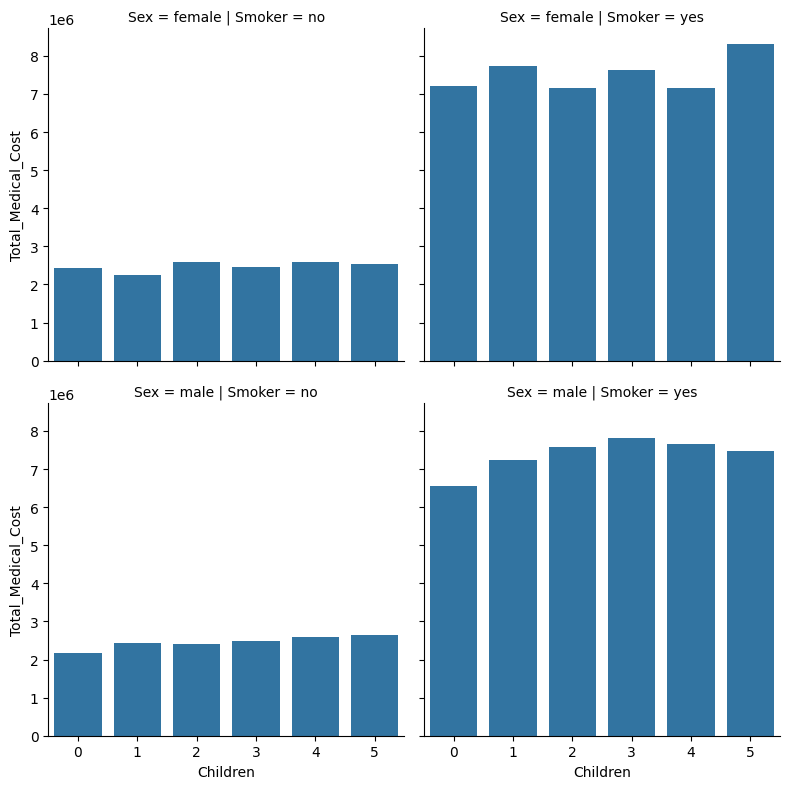

In [32]:
g = sns.FacetGrid(children_medical_cost, col='Smoker', row='Sex', height=4)
g.map(sns.barplot, 'Children', 'Total_Medical_Cost')
plt.show()

**What is the relationship between age and bmi (for smoker and sex)?**

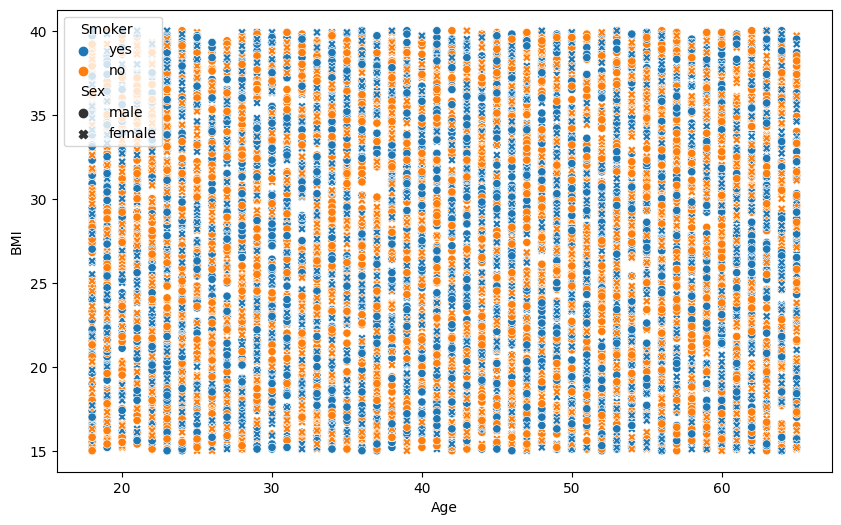

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(df,x='Age',y='BMI',hue='Smoker',style='Sex')
plt.xlabel('Age')
plt.ylabel('BMI')
plt.show()

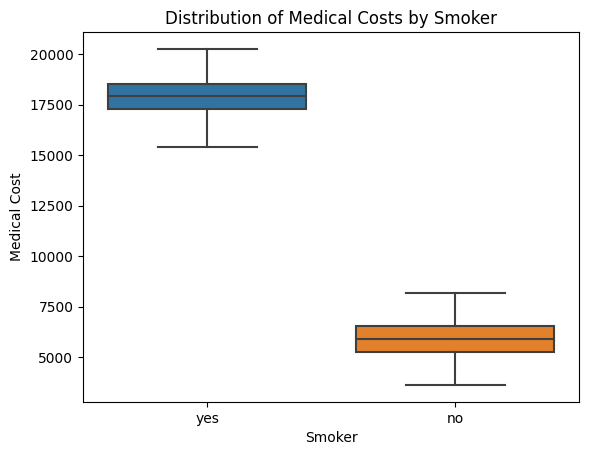

In [34]:
sns.boxplot(x='Smoker', y='Medical Cost',data=df)
plt.xlabel('Smoker')
plt.ylabel('Medical Cost')
plt.title('Distribution of Medical Costs by Smoker')
plt.show()

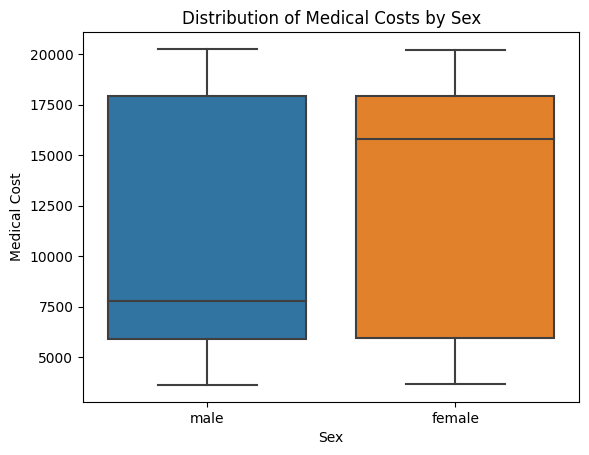

In [35]:
sns.boxplot(x='Sex', y='Medical Cost',data=df)
plt.xlabel('Sex')
plt.ylabel('Medical Cost')
plt.title('Distribution of Medical Costs by Sex')
plt.show()

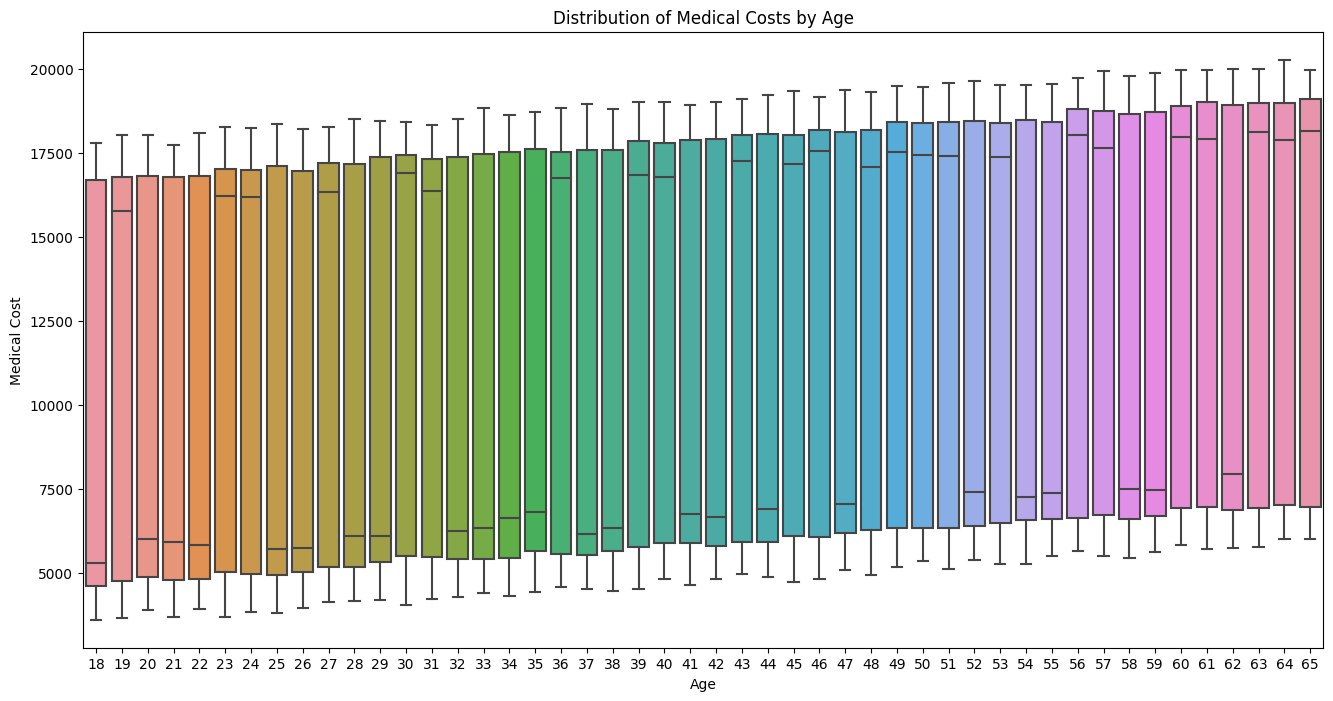

In [36]:
plt.figure(figsize=(16,8))
sns.boxplot(x='Age', y='Medical Cost', data=df)
plt.xlabel('Age')
plt.ylabel('Medical Cost')
plt.title('Distribution of Medical Costs by Age')
plt.show()

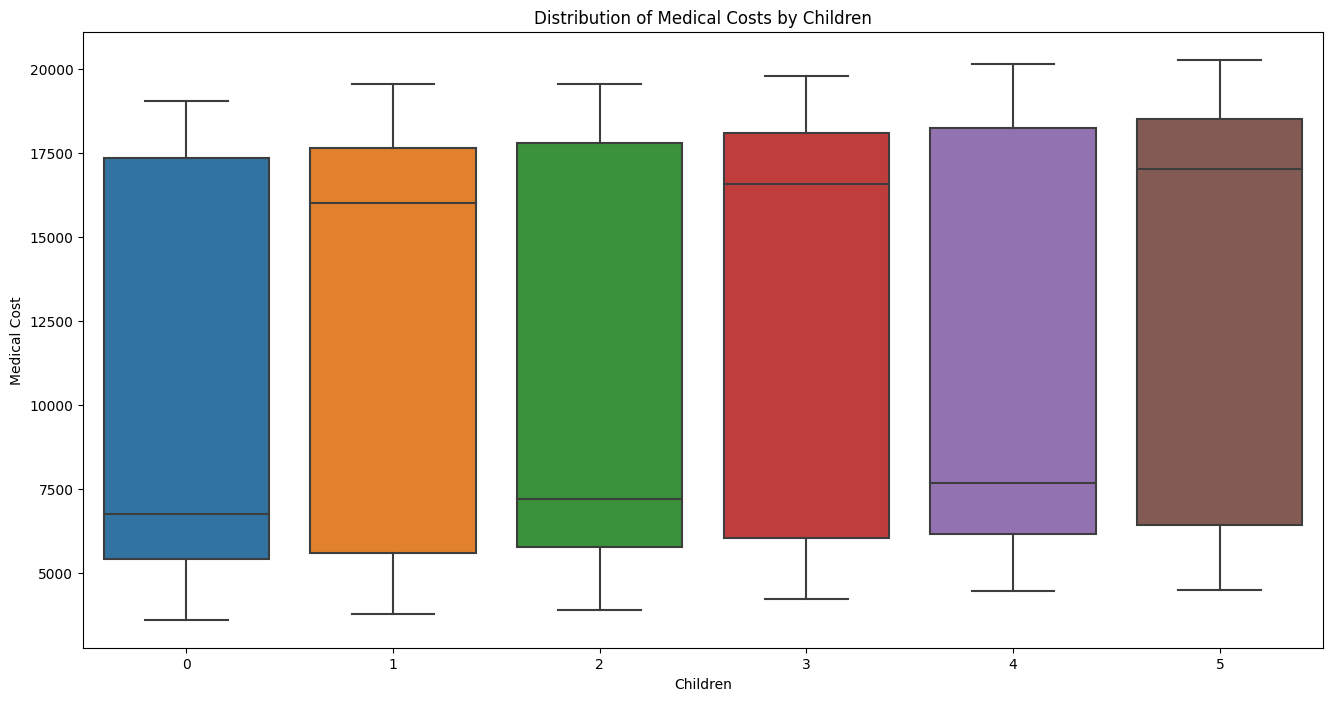

In [37]:
plt.figure(figsize=(16,8))
sns.boxplot(x='Children', y='Medical Cost', data=df)
plt.xlabel('Children')
plt.ylabel('Medical Cost')
plt.title('Distribution of Medical Costs by Children')
plt.show()

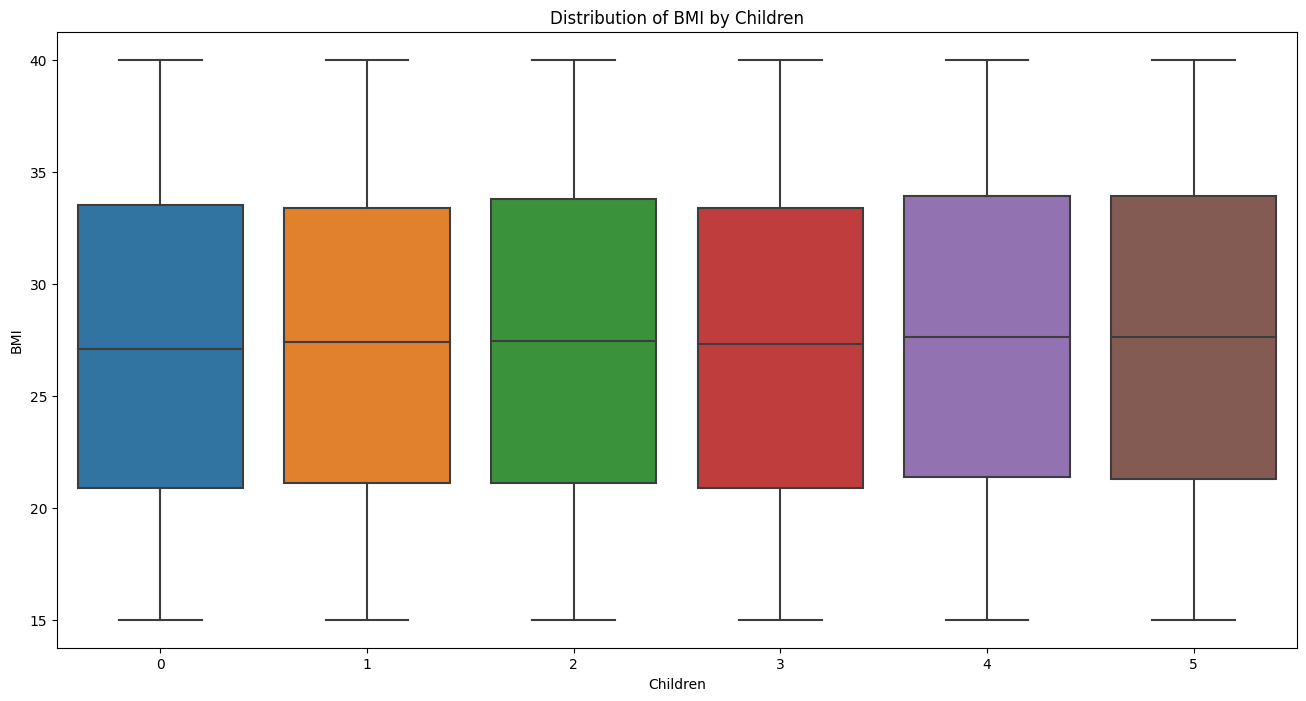

In [38]:
plt.figure(figsize=(16,8))
sns.boxplot(x='Children', y='BMI', data=df)
plt.xlabel('Children')
plt.ylabel('BMI')
plt.title('Distribution of BMI by Children')
plt.show() 

**What is the most and least expensive region in terms of medical costs?**

In [39]:
most_region=df.groupby('Region')
most_region

In [40]:
most_region['Medical Cost'].sum().sort_values(ascending=False).head(1) 

Region
northeast    29952916.24
Name: Medical Cost, dtype: float64

In [41]:
most_region['Medical Cost'].sum().sort_values(ascending=True).head(1) 

Region
northwest    29479104.73
Name: Medical Cost, dtype: float64

**What is the region with the most and least sex smokers?**

In [42]:
region_smokers= df.groupby(['Smoker','Region'])['Sex'].value_counts().reset_index()

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:712: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 1200x600 with 0 Axes>

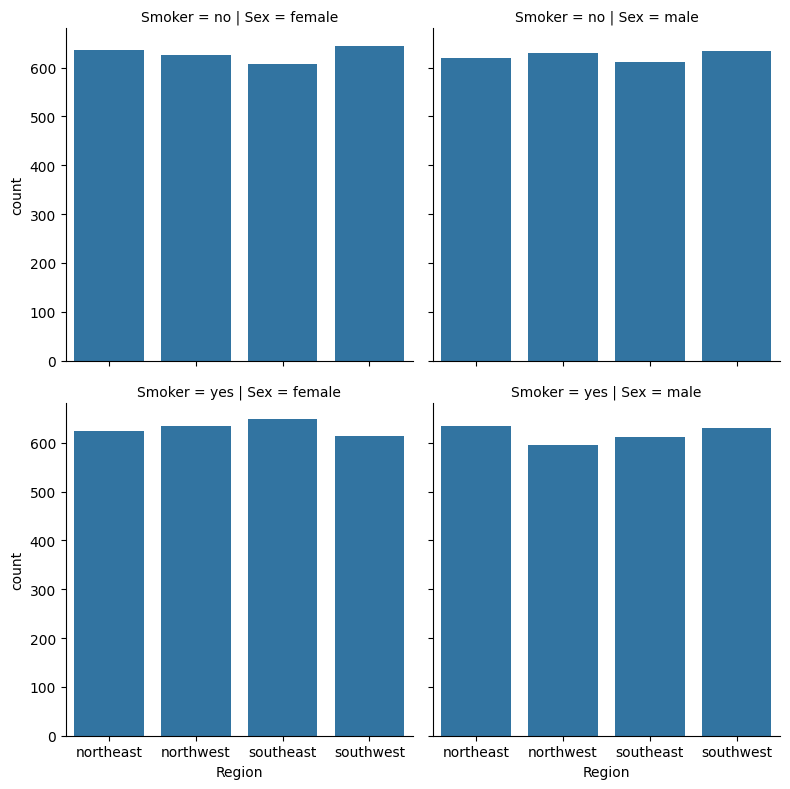

In [43]:
plt.figure(figsize=(12,6))
g = sns.FacetGrid(region_smokers, col="Sex", row="Smoker",height=4)
g.map(sns.barplot, "Region", "count")
plt.show()

**I hope I covered all aspects Don't forget to upvote me**